# 🔬 VoltVision — Advanced Model Problem Analysis

Model training improved the Kaggle result, so the next step is **not** to throw more random features or more tuning at the model.

This notebook asks a harder question:

> **Where is the current system weak, why is it weak, and what evidence should drive the next round of feature engineering and model training?**

We will diagnose the current LightGBM / XGBoost / CatBoost system from several angles: generalization, OOF stability, ranking errors, subgroup weakness, feature interactions, SHAP, permutation importance, redundancy, ablation, train/test drift, model disagreement, seed sensitivity, and learning curves.

The goal is evidence. We will not assume a feature is bad or a segment is difficult until the diagnostics show it.

## Imports and Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings

from pathlib import Path
from scipy.stats import ks_2samp, spearmanr

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss, roc_curve
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

import lightgbm as lgb
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    SHAP_AVAILABLE = False

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

RANDOM_STATE = 42

In [2]:
# Real diagnostic run
FAST_MODE = False

# Expensive sections can be turned off independently when needed.
RUN_SHAP = True
RUN_SHAP_INTERACTIONS = True
RUN_PERMUTATION = True
RUN_ABLATION = True
RUN_ADVERSARIAL = True
RUN_SEED_STABILITY = True
RUN_LEARNING_CURVE = True

OOF_FOLDS = 2 if FAST_MODE else 5
BOOTSTRAP_ROUNDS = 60 if FAST_MODE else 300

FAST_TRAIN_ROWS = 20_000
FAST_TEST_ROWS = 12_000
HEAVY_SAMPLE = 12_000 if FAST_MODE else 200_000
SHAP_SAMPLE = 800 if FAST_MODE else 20_000
SHAP_INTERACTION_SAMPLE = 250 if FAST_MODE else 1_500
PERMUTATION_SAMPLE = 2_000 if FAST_MODE else 30_000
DOMAIN_SAMPLE = 8_000 if FAST_MODE else 200_000

SEEDS = [42, 123] if FAST_MODE else [42, 123, 2026, 3407, 777]
LEARNING_FRACTIONS = [0.25, 0.50, 1.00] if FAST_MODE else [0.10, 0.25, 0.50, 0.75, 1.00]

The notebook has a `FAST_MODE` only for debugging the notebook itself. Keep it **False** for the real analysis. The heavy diagnostics use controlled samples where a full 668k-row run would add a lot of compute without adding much diagnostic value.

## Load Processed Data, Raw Data, and Training Metadata

In [3]:
data_path = Path("../data")
processed_path = data_path / "processed"
models_path = Path("../models")
analysis_path = Path("../analysis")
analysis_path.mkdir(parents=True, exist_ok=True)

X = pd.read_csv(processed_path / "X_train.csv")
y = pd.read_csv(processed_path / "y_train.csv").squeeze("columns")
X_kaggle = pd.read_csv(processed_path / "X_test.csv")

raw_train = pd.read_csv(data_path / "train.csv")
raw_test = pd.read_csv(data_path / "test.csv")

train_ids_path = processed_path / "train_ids.csv"
train_ids = (
    pd.read_csv(train_ids_path).squeeze("columns")
    if train_ids_path.exists()
    else raw_train["id"].copy()
)

metadata_path = models_path / "training_metadata.json"
if metadata_path.exists():
    with open(metadata_path, "r", encoding="utf-8") as f:
        metadata = json.load(f)
else:
    metadata = {}

print("Processed train:", X.shape)
print("Processed Kaggle test:", X_kaggle.shape)
print("Raw train:", raw_train.shape)
print("Training metadata found:", bool(metadata))

Processed train: (668665, 25)
Processed Kaggle test: (286571, 25)
Raw train: (668665, 15)
Training metadata found: True


In [4]:
# Keep every table perfectly row-aligned in smoke-test mode.
if FAST_MODE:
    all_idx = np.arange(len(X))
    keep_idx, _ = train_test_split(
        all_idx,
        train_size=min(FAST_TRAIN_ROWS, len(all_idx) - 1),
        stratify=y,
        random_state=RANDOM_STATE
    )
    keep_idx = np.sort(keep_idx)

    X = X.iloc[keep_idx].reset_index(drop=True)
    y = y.iloc[keep_idx].reset_index(drop=True)
    raw_train = raw_train.iloc[keep_idx].reset_index(drop=True)
    train_ids = train_ids.iloc[keep_idx].reset_index(drop=True)

    if len(X_kaggle) > FAST_TEST_ROWS:
        test_idx = np.random.default_rng(RANDOM_STATE).choice(len(X_kaggle), FAST_TEST_ROWS, replace=False)
        test_idx = np.sort(test_idx)
        X_kaggle = X_kaggle.iloc[test_idx].reset_index(drop=True)
        raw_test = raw_test.iloc[test_idx].reset_index(drop=True)

print("Analysis train rows:", len(X))
print("Analysis test rows:", len(X_kaggle))

Analysis train rows: 668665
Analysis test rows: 286571


## Reconstruct the Current Winning System

In [5]:
fallback_lgb_params = {
    "learning_rate": 0.035,
    "num_leaves": 31,
    "max_depth": -1,
    "min_child_samples": 30,
    "subsample": 0.90,
    "colsample_bytree": 0.90,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0
}

lgb_params = fallback_lgb_params.copy()
lgb_params.update(metadata.get("lightgbm_tuned_params", {}))

lgb_rounds = int(metadata.get("lightgbm_rounds", 900))
xgb_rounds = int(metadata.get("xgboost_rounds", 700))
cat_rounds = int(metadata.get("catboost_rounds", 800))

if FAST_MODE:
    lgb_rounds = min(lgb_rounds, 160)
    xgb_rounds = min(xgb_rounds, 140)
    cat_rounds = min(cat_rounds, 160)

stored_weights = metadata.get("blend_weights", {
    "LightGBM": 0.40,
    "XGBoost": 0.30,
    "CatBoost": 0.30
})

stored_validation_auc = metadata.get("validation_auc", {})
stored_best_single = metadata.get("best_single_model", "Tuned LightGBM")

print("Stored best single model:", stored_best_single)
print("Stored blend weights:", stored_weights)
print("Rounds:", {"LightGBM": lgb_rounds, "XGBoost": xgb_rounds, "CatBoost": cat_rounds})
print("Stored validation AUC:", stored_validation_auc)

Stored best single model: Tuned LightGBM
Stored blend weights: {'LightGBM': 0.7, 'XGBoost': 0.2, 'CatBoost': 0.1}
Rounds: {'LightGBM': 1766, 'XGBoost': 744, 'CatBoost': 1255}
Stored validation AUC: {'XGBoost': 0.9418471373072973, 'Tuned LightGBM': 0.9421013556330333, 'CatBoost': 0.9416390189054267, 'Blend': 0.9421682211590681}


In [6]:
def make_lgb(seed=RANDOM_STATE, rounds=lgb_rounds):
    return LGBMClassifier(
        n_estimators=rounds,
        **lgb_params,
        random_state=seed,
        n_jobs=-1,
        verbosity=-1
    )


def make_xgb(seed=RANDOM_STATE, rounds=xgb_rounds):
    return XGBClassifier(
        n_estimators=rounds,
        learning_rate=0.04,
        max_depth=6,
        min_child_weight=3,
        subsample=0.90,
        colsample_bytree=0.90,
        reg_alpha=0.0,
        reg_lambda=1.0,
        eval_metric="auc",
        tree_method="hist",
        n_jobs=-1,
        random_state=seed
    )


def make_cat(seed=RANDOM_STATE, rounds=cat_rounds):
    return CatBoostClassifier(
        iterations=rounds,
        learning_rate=0.04,
        depth=7,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=seed,
        thread_count=-1,
        verbose=False,
        allow_writing_files=False
    )

In [7]:
checks = {
    "25 processed features": X.shape[1] == 25,
    "train/test columns identical": X.columns.equals(X_kaggle.columns),
    "no train missing values": X.isna().sum().sum() == 0,
    "no test missing values": X_kaggle.isna().sum().sum() == 0,
    "id excluded": "id" not in X.columns,
    "target excluded": "Will_Buy_EV" not in X.columns,
    "raw/processed train aligned": len(raw_train) == len(X) == len(y),
}

if metadata.get("features"):
    checks["metadata feature order matches"] = list(X.columns) == metadata["features"]

pd.Series(checks, name="Passed")

25 processed features             True
train/test columns identical      True
no train missing values           True
no test missing values            True
id excluded                       True
target excluded                   True
raw/processed train aligned       True
metadata feature order matches    True
Name: Passed, dtype: bool

Before diagnosing model quality, we verify the **data contract**. If feature order, row alignment, IDs, or metadata do not match the training notebook, every downstream explanation becomes unreliable.

## Recreate the Original Holdout

In [8]:
idx = np.arange(len(X))
train_idx, valid_idx = train_test_split(
    idx,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

X_train = X.iloc[train_idx]
y_train = y.iloc[train_idx]
X_valid = X.iloc[valid_idx]
y_valid = y.iloc[valid_idx]

print("Train:", X_train.shape, "| positive rate:", round(y_train.mean(), 4))
print("Valid:", X_valid.shape, "| positive rate:", round(y_valid.mean(), 4))

Train: (534932, 25) | positive rate: 0.1746
Valid: (133733, 25) | positive rate: 0.1746


In [9]:
holdout_models = {
    "Tuned LightGBM": make_lgb(),
    "XGBoost": make_xgb(),
    "CatBoost": make_cat()
}

holdout_train_prob = {}
holdout_valid_prob = {}

for name, model in holdout_models.items():
    model.fit(X_train, y_train)
    holdout_train_prob[name] = model.predict_proba(X_train)[:, 1]
    holdout_valid_prob[name] = model.predict_proba(X_valid)[:, 1]
    print(name, "done")

Tuned LightGBM done
XGBoost done
CatBoost done


In [10]:
holdout_train_prob["Blend"] = (
    stored_weights.get("LightGBM", 0.0) * holdout_train_prob["Tuned LightGBM"] +
    stored_weights.get("XGBoost", 0.0) * holdout_train_prob["XGBoost"] +
    stored_weights.get("CatBoost", 0.0) * holdout_train_prob["CatBoost"]
)

holdout_valid_prob["Blend"] = (
    stored_weights.get("LightGBM", 0.0) * holdout_valid_prob["Tuned LightGBM"] +
    stored_weights.get("XGBoost", 0.0) * holdout_valid_prob["XGBoost"] +
    stored_weights.get("CatBoost", 0.0) * holdout_valid_prob["CatBoost"]
)

current_choice = (
    max(stored_validation_auc, key=stored_validation_auc.get)
    if stored_validation_auc
    else max(holdout_valid_prob, key=lambda k: roc_auc_score(y_valid, holdout_valid_prob[k]))
)

if current_choice not in holdout_valid_prob:
    current_choice = "Blend" if "Blend" in holdout_valid_prob else stored_best_single

print("Current system selected for diagnosis:", current_choice)

Current system selected for diagnosis: Blend


## Generalization / Overfitting Diagnosis

In [11]:
generalization_rows = []

for name in holdout_valid_prob:
    train_auc = roc_auc_score(y_train, holdout_train_prob[name])
    valid_auc = roc_auc_score(y_valid, holdout_valid_prob[name])
    train_ll = log_loss(y_train, holdout_train_prob[name], labels=[0, 1])
    valid_ll = log_loss(y_valid, holdout_valid_prob[name], labels=[0, 1])

    generalization_rows.append({
        "Model": name,
        "Train_AUC": train_auc,
        "Valid_AUC": valid_auc,
        "AUC_Gap": train_auc - valid_auc,
        "Train_LogLoss": train_ll,
        "Valid_LogLoss": valid_ll,
        "LogLoss_Gap": valid_ll - train_ll
    })

generalization_df = pd.DataFrame(generalization_rows).sort_values("Valid_AUC", ascending=False)
generalization_df

,Model,Train_AUC,Valid_AUC,AUC_Gap,Train_LogLoss,Valid_LogLoss,LogLoss_Gap
3,Blend,0.946701,0.942168,0.004532,0.217923,0.225833,0.007910
0,Tuned LightGBM,0.946097,0.942101,0.003996,0.218942,0.225964,0.007022
1,XGBoost,0.948254,0.941847,0.006407,0.215203,0.226375,0.011172
2,CatBoost,0.945949,0.941638,0.004310,0.219211,0.226670,0.007459


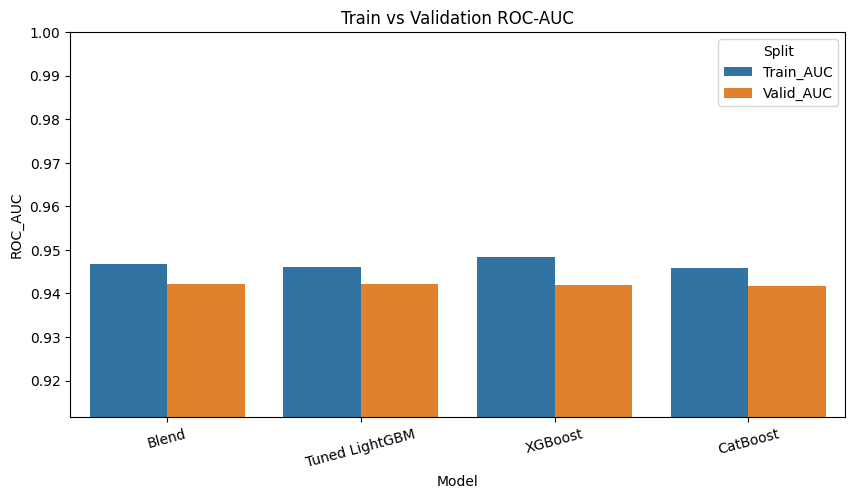

In [12]:
plot_df = generalization_df.melt(
    id_vars="Model",
    value_vars=["Train_AUC", "Valid_AUC"],
    var_name="Split",
    value_name="ROC_AUC"
)

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="Model", y="ROC_AUC", hue="Split")
plt.ylim(max(0.50, plot_df["ROC_AUC"].min() - 0.03), 1.0)
plt.title("Train vs Validation ROC-AUC")
plt.xticks(rotation=15)
plt.show()

The key number here is the **AUC gap**. A strong train score with a noticeably weaker validation score points toward variance / overfitting. If both are limited, the bottleneck is more likely feature information or model bias.

## OOF Cross-Validation and Stability

In [13]:
cv = StratifiedKFold(n_splits=OOF_FOLDS, shuffle=True, random_state=RANDOM_STATE)

oof_lgb = np.zeros(len(X))
oof_xgb = np.zeros(len(X))
oof_cat = np.zeros(len(X))

fold_rows = []
fold_importance_rows = []

for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y), start=1):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    lgb_fold = make_lgb(seed=RANDOM_STATE + fold)
    xgb_fold = make_xgb(seed=RANDOM_STATE + fold)
    cat_fold = make_cat(seed=RANDOM_STATE + fold)

    lgb_fold.fit(X_tr, y_tr)
    xgb_fold.fit(X_tr, y_tr, verbose=False)
    cat_fold.fit(X_tr, y_tr, verbose=False)

    p_lgb = lgb_fold.predict_proba(X_va)[:, 1]
    p_xgb = xgb_fold.predict_proba(X_va)[:, 1]
    p_cat = cat_fold.predict_proba(X_va)[:, 1]

    oof_lgb[va_idx] = p_lgb
    oof_xgb[va_idx] = p_xgb
    oof_cat[va_idx] = p_cat

    fold_rows.extend([
        {"Fold": fold, "Model": "LightGBM", "AUC": roc_auc_score(y_va, p_lgb)},
        {"Fold": fold, "Model": "XGBoost", "AUC": roc_auc_score(y_va, p_xgb)},
        {"Fold": fold, "Model": "CatBoost", "AUC": roc_auc_score(y_va, p_cat)},
    ])

    for feature, importance in zip(X.columns, lgb_fold.feature_importances_):
        fold_importance_rows.append({"Fold": fold, "Feature": feature, "Importance": importance})

    print(f"Fold {fold}/{OOF_FOLDS} complete")

fold_auc_df = pd.DataFrame(fold_rows)
fold_auc_df

Fold 1/5 complete
Fold 2/5 complete
Fold 3/5 complete
Fold 4/5 complete
Fold 5/5 complete


,Fold,Model,AUC
0,1,LightGBM,0.941074
1,1,XGBoost,0.940859
2,1,CatBoost,0.940651
3,2,LightGBM,0.942032
4,2,XGBoost,0.941731
5,2,CatBoost,0.941703
6,3,LightGBM,0.943239
7,3,XGBoost,0.943115
8,3,CatBoost,0.943002
9,4,LightGBM,0.942740


In [14]:
cv_summary = (
    fold_auc_df.groupby("Model")["AUC"]
    .agg(["mean", "std", "min", "max"])
    .sort_values("mean", ascending=False)
)
cv_summary

,mean,std,min,max
Model,,,,
LightGBM,0.942290,0.000814,0.941074,0.943239
XGBoost,0.942056,0.000849,0.940859,0.943115
CatBoost,0.941907,0.000865,0.940651,0.943002


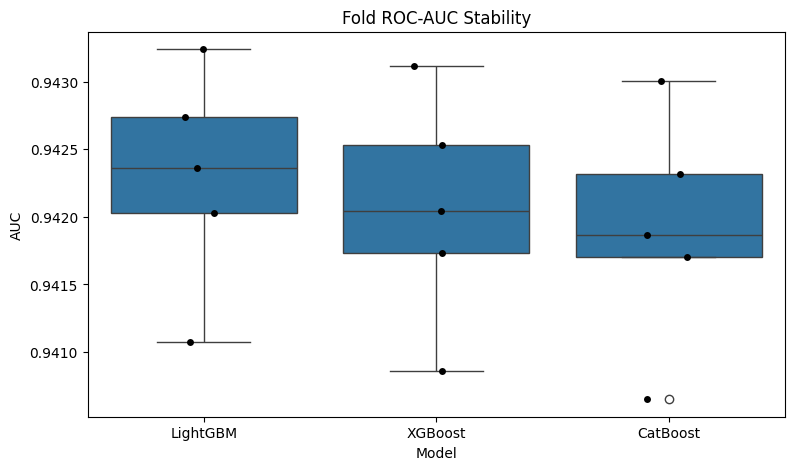

In [15]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=fold_auc_df, x="Model", y="AUC")
sns.stripplot(data=fold_auc_df, x="Model", y="AUC", color="black", size=5)
plt.title("Fold ROC-AUC Stability")
plt.show()

In [16]:
fold_importance_df = pd.DataFrame(fold_importance_rows)
importance_stability = (
    fold_importance_df.groupby("Feature")["Importance"]
    .agg(["mean", "std"])
    .sort_values("mean", ascending=False)
    .reset_index()
)

importance_stability.head(15)

,Feature,mean,std
0,Daily_Commute_km,"3,659.200000",120.298379
1,Annual_Income_USD,"3,319.200000",68.170375
2,Income_x_Concern,"3,132.000000",95.679151
3,Age,"2,732.800000",107.166693
4,Subsidy_x_Income,"2,636.400000",93.681909
5,Income_Per_Car,"2,601.000000",84.068425
6,Total_Charging_Stations,"1,547.200000",70.818077
7,Charging_Stations_Near_Work,"1,376.000000",34.044089
8,Charging_Stations_Near_Home,"1,336.600000",64.879118
9,Environmental_Concern_Level,483.800000,26.929538


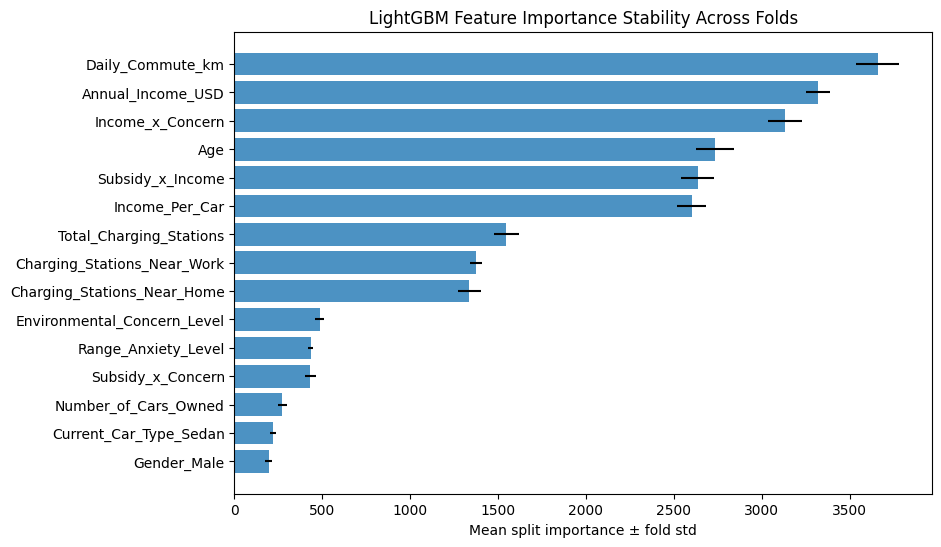

In [17]:
top_imp = importance_stability.head(15).sort_values("mean")
plt.figure(figsize=(9, 6))
plt.barh(top_imp["Feature"], top_imp["mean"], xerr=top_imp["std"], alpha=0.8)
plt.title("LightGBM Feature Importance Stability Across Folds")
plt.xlabel("Mean split importance ± fold std")
plt.show()

Stable CV matters more than one lucky holdout. The feature-importance error bars also tell us whether the model relies on the same signals across folds or whether a feature's importance is unstable.

## OOF Blend and Validation-Overfitting Check

In [18]:
oof_single_auc = {
    "LightGBM": roc_auc_score(y, oof_lgb),
    "XGBoost": roc_auc_score(y, oof_xgb),
    "CatBoost": roc_auc_score(y, oof_cat)
}

weight_values = np.arange(0.0, 1.001, 0.05)
best_oof_auc = -np.inf
best_oof_weights = None
best_oof_blend = None

for lgb_w in weight_values:
    for xgb_w in weight_values:
        cat_w = 1.0 - lgb_w - xgb_w
        if cat_w < -1e-12:
            continue
        cat_w = max(cat_w, 0.0)

        pred = lgb_w * oof_lgb + xgb_w * oof_xgb + cat_w * oof_cat
        auc = roc_auc_score(y, pred)

        if auc > best_oof_auc:
            best_oof_auc = auc
            best_oof_weights = {
                "LightGBM": round(float(lgb_w), 2),
                "XGBoost": round(float(xgb_w), 2),
                "CatBoost": round(float(cat_w), 2)
            }
            best_oof_blend = pred

print("OOF single AUC:", {k: round(v, 6) for k, v in oof_single_auc.items()})
print("OOF blend AUC:", round(best_oof_auc, 6))
print("OOF blend weights:", best_oof_weights)
print("Old holdout weights:", stored_weights)

OOF single AUC: {'LightGBM': 0.942282, 'XGBoost': 0.942048, 'CatBoost': 0.941901}
OOF blend AUC: 0.942359
OOF blend weights: {'LightGBM': 0.6, 'XGBoost': 0.2, 'CatBoost': 0.2}
Old holdout weights: {'LightGBM': 0.7, 'XGBoost': 0.2, 'CatBoost': 0.1}


In [19]:
oof_predictions = pd.DataFrame({
    "id": train_ids.values,
    "target": y.values,
    "LightGBM": oof_lgb,
    "XGBoost": oof_xgb,
    "CatBoost": oof_cat,
    "OOF_Blend": best_oof_blend
})

oof_predictions.head()

,id,target,LightGBM,XGBoost,CatBoost,OOF_Blend
0,0,0,0.000244,0.000185,0.000096,0.000203
1,1,0,0.001761,0.002106,0.001778,0.001833
2,2,1,0.790907,0.753620,0.723847,0.770037
3,3,0,0.001326,0.001527,0.001593,0.001420
4,4,0,0.001967,0.001573,0.001452,0.001785


This is one of the most important checks. Notebook 03 searched blend weights on the same holdout used to judge the blend. OOF predictions give us a much cleaner view of whether the ensemble gain survives across the full training set.

## Bootstrap AUC Confidence Interval

In [20]:
rng = np.random.default_rng(RANDOM_STATE)
bootstrap_auc = []

for _ in range(BOOTSTRAP_ROUNDS):
    sample_idx = rng.integers(0, len(y), len(y))
    y_b = y.iloc[sample_idx].values

    if len(np.unique(y_b)) < 2:
        continue

    bootstrap_auc.append(
        roc_auc_score(y_b, best_oof_blend[sample_idx])
    )

bootstrap_auc = np.array(bootstrap_auc)
ci_low, ci_high = np.percentile(bootstrap_auc, [2.5, 97.5])

print("OOF AUC:", round(best_oof_auc, 6))
print("95% bootstrap CI:", round(ci_low, 6), "to", round(ci_high, 6))
print("Bootstrap std:", round(bootstrap_auc.std(), 6))

OOF AUC: 0.942359
95% bootstrap CI: 0.94172 to 0.942934
Bootstrap std: 0.000301


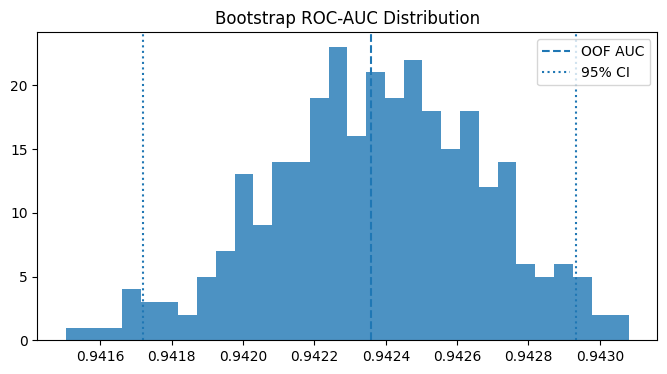

In [21]:
plt.figure(figsize=(8, 4))
plt.hist(bootstrap_auc, bins=30, alpha=0.8)
plt.axvline(best_oof_auc, linestyle="--", label="OOF AUC")
plt.axvline(ci_low, linestyle=":", label="95% CI")
plt.axvline(ci_high, linestyle=":")
plt.title("Bootstrap ROC-AUC Distribution")
plt.legend()
plt.show()

The confidence interval stops us from overreacting to tiny AUC changes. If a future experiment improves by less than the natural validation uncertainty, we should treat that gain cautiously.

## Probability Separation and Uncertainty

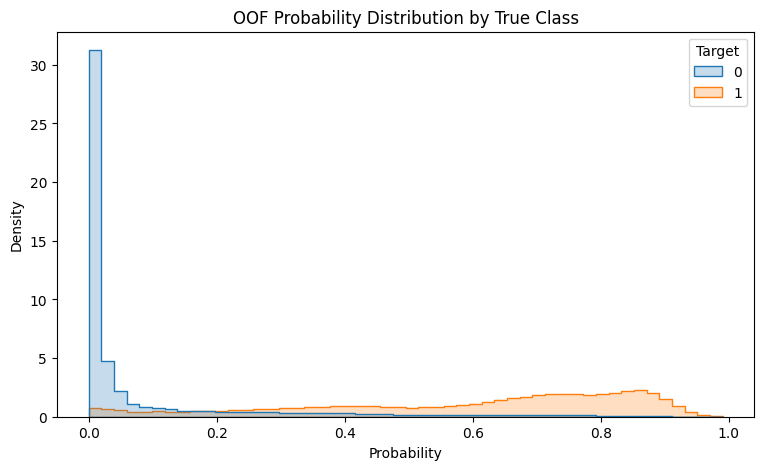

In [22]:
probability_df = pd.DataFrame({
    "Target": y.values,
    "Probability": best_oof_blend
})

plt.figure(figsize=(9, 5))
sns.histplot(
    data=probability_df,
    x="Probability",
    hue="Target",
    bins=50,
    stat="density",
    common_norm=False,
    element="step"
)
plt.title("OOF Probability Distribution by True Class")
plt.show()

In [23]:
probability_df["Bin"] = pd.cut(probability_df["Probability"], bins=np.linspace(0, 1, 21), include_lowest=True)
uncertainty_table = (
    probability_df.groupby("Bin", observed=False)
    .agg(
        Rows=("Target", "size"),
        Actual_Rate=("Target", "mean"),
        Mean_Probability=("Probability", "mean")
    )
    .reset_index()
)

uncertainty_table["Absolute_Gap"] = (
    uncertainty_table["Actual_Rate"] - uncertainty_table["Mean_Probability"]
).abs()

uncertainty_table

,Bin,Rows,Actual_Rate,Mean_Probability,Absolute_Gap
0,"(-0.001, 0.05]",412701,0.009275,0.009313,0.000037
1,"(0.05, 0.1]",32987,0.071786,0.071341,0.000445
2,"(0.1, 0.15]",20616,0.121702,0.123252,0.001550
3,"(0.15, 0.2]",15893,0.168879,0.174622,0.005743
4,"(0.2, 0.25]",14139,0.223566,0.224561,0.000994
5,"(0.25, 0.3]",13965,0.278625,0.275266,0.003359
6,"(0.3, 0.35]",14204,0.326669,0.324864,0.001805
7,"(0.35, 0.4]",13771,0.374555,0.374755,0.000200
8,"(0.4, 0.45]",12471,0.419293,0.424306,0.005014
9,"(0.45, 0.5]",10170,0.473845,0.473957,0.000112


The overlap between the two class distributions is the model's uncertainty zone. That region is where new interactions or better representations have the greatest chance to improve ranking.

## Calibration Diagnosis

In [24]:
brier = brier_score_loss(y, best_oof_blend)

prob_true, prob_pred = calibration_curve(
    y,
    best_oof_blend,
    n_bins=10,
    strategy="quantile"
)

def expected_calibration_error(y_true, prob, bins=10):
    edges = np.linspace(0, 1, bins + 1)
    ids = np.digitize(prob, edges[1:-1], right=True)
    ece = 0.0

    for b in range(bins):
        mask = ids == b
        if mask.sum() == 0:
            continue
        ece += mask.mean() * abs(y_true[mask].mean() - prob[mask].mean())

    return float(ece)

ece = expected_calibration_error(y.values, best_oof_blend, bins=10)

print("Brier score:", round(brier, 6))
print("Expected calibration error:", round(ece, 6))

Brier score: 0.070824
Expected calibration error: 0.000645


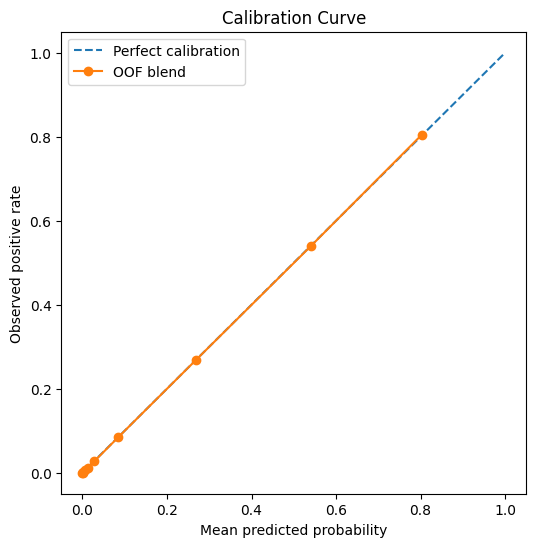

In [25]:
plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.plot(prob_pred, prob_true, marker="o", label="OOF blend")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed positive rate")
plt.title("Calibration Curve")
plt.legend()
plt.show()

Calibration is not the Kaggle metric, but it reveals whether probability confidence is distorted. AUC can still be strong while probability levels are systematically too high or too low.

## Advanced Error Segmentation

In [26]:
diagnostic_df = raw_train.copy()
diagnostic_df["Actual"] = y.values
diagnostic_df["Probability"] = best_oof_blend
diagnostic_df["Predicted"] = (diagnostic_df["Probability"] >= 0.50).astype(int)

diagnostic_df["Error_Type"] = "True Negative"
diagnostic_df.loc[(diagnostic_df["Actual"] == 1) & (diagnostic_df["Predicted"] == 1), "Error_Type"] = "True Positive"
diagnostic_df.loc[(diagnostic_df["Actual"] == 0) & (diagnostic_df["Predicted"] == 1), "Error_Type"] = "False Positive"
diagnostic_df.loc[(diagnostic_df["Actual"] == 1) & (diagnostic_df["Predicted"] == 0), "Error_Type"] = "False Negative"

diagnostic_df["Error_Type"].value_counts()

Error_Type
True Negative     522630
True Positive      78492
False Negative     38287
False Positive     29256
Name: count, dtype: int64

In [27]:
profile_cols = [
    "Age",
    "Annual_Income_USD",
    "Daily_Commute_km",
    "Number_of_Cars_Owned",
    "Charging_Stations_Near_Home",
    "Charging_Stations_Near_Work",
    "Environmental_Concern_Level"
]

z = diagnostic_df[profile_cols].copy()
z = (z - z.mean()) / z.std(ddof=0).replace(0, 1)
z["Error_Type"] = diagnostic_df["Error_Type"].values

error_profile = z.groupby("Error_Type")[profile_cols].mean()
error_profile

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level
Error_Type,,,,,,,
False Negative,-0.006375,0.066563,-0.049963,-0.003915,-0.033902,-0.027382,0.437589
False Positive,-0.012873,0.507693,-0.094882,0.001004,-0.037296,-0.024570,1.186423
True Negative,0.004339,-0.138068,0.027591,-0.001949,0.010031,0.007316,-0.291840
True Positive,-0.020985,0.697610,-0.123973,0.014510,-0.036354,-0.026195,1.287528


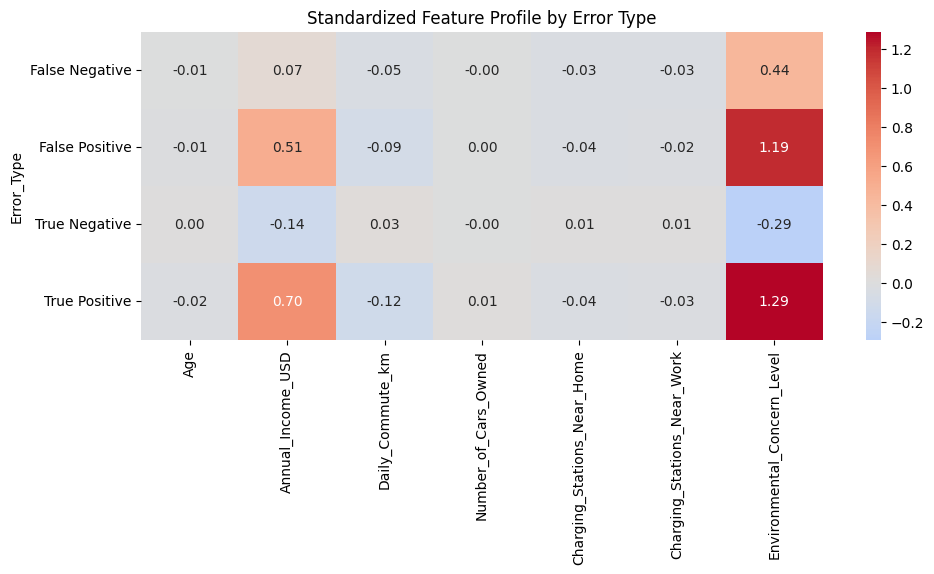

In [28]:
plt.figure(figsize=(11, 4))
sns.heatmap(error_profile, annot=True, fmt=".2f", center=0, cmap="coolwarm")
plt.title("Standardized Feature Profile by Error Type")
plt.show()

Threshold errors are only diagnostic because Kaggle uses ROC-AUC. Their value is that they expose **systematic customer profiles** the model tends to overestimate or underestimate.

## Hard Example Mining

In [29]:
positive_probs = diagnostic_df.loc[diagnostic_df["Actual"] == 1, "Probability"]
negative_probs = diagnostic_df.loc[diagnostic_df["Actual"] == 0, "Probability"]

hard_fn_threshold = 0.20 if (positive_probs <= 0.20).any() else positive_probs.quantile(0.10)
hard_fp_threshold = 0.80 if (negative_probs >= 0.80).any() else negative_probs.quantile(0.90)

hard_fn = diagnostic_df[(diagnostic_df["Actual"] == 1) & (diagnostic_df["Probability"] <= hard_fn_threshold)].copy()
hard_fp = diagnostic_df[(diagnostic_df["Actual"] == 0) & (diagnostic_df["Probability"] >= hard_fp_threshold)].copy()

print("Hard-FN threshold:", round(float(hard_fn_threshold), 4), "| rows:", len(hard_fn))
print("Hard-FP threshold:", round(float(hard_fp_threshold), 4), "| rows:", len(hard_fp))

Hard-FN threshold: 0.2 | rows: 11389
Hard-FP threshold: 0.8 | rows: 4655


In [30]:
hard_profile = pd.DataFrame({
    "Hard False Negative": hard_fn[profile_cols].mean(),
    "Hard False Positive": hard_fp[profile_cols].mean(),
    "Overall": diagnostic_df[profile_cols].mean()
}).T

hard_profile

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level
Hard False Negative,47.010010,"83,355.410835",32.185662,1.705066,4.947932,7.133901,2.980156
Hard False Positive,46.702256,"116,010.557035",29.100580,1.731257,4.807519,7.020193,4.981740
Overall,47.039171,"84,769.266989",32.158298,1.712626,4.960408,7.176314,2.935477


These are the most informative mistakes: rows where the model is not merely wrong, but **confidently wrong**. New features should be tested against these cohorts first.

## Subgroup ROC-AUC

In [31]:
def subgroup_auc_table(df, group_col, min_rows=300):
    rows = []

    for level, part in df.groupby(group_col, observed=False):
        if len(part) < min_rows or part["Actual"].nunique() < 2:
            continue

        rows.append({
            "Group": group_col,
            "Level": str(level),
            "Rows": len(part),
            "Positive_Rate": part["Actual"].mean(),
            "ROC_AUC": roc_auc_score(part["Actual"], part["Probability"])
        })

    return pd.DataFrame(rows)


diagnostic_df["Income_Band"] = pd.qcut(diagnostic_df["Annual_Income_USD"], 4, duplicates="drop")
diagnostic_df["Commute_Band"] = pd.qcut(diagnostic_df["Daily_Commute_km"], 4, duplicates="drop")
diagnostic_df["Age_Band"] = pd.cut(diagnostic_df["Age"], bins=[0, 30, 45, 60, 100], include_lowest=True)

subgroup_frames = []
for col in [
    "Subsidy_Available",
    "Home_Charging_Possible",
    "Range_Anxiety_Level",
    "City_Type",
    "Current_Car_Type",
    "Gender",
    "Environmental_Concern_Level",
    "Income_Band",
    "Commute_Band",
    "Age_Band"
]:
    subgroup_frames.append(subgroup_auc_table(diagnostic_df, col, min_rows=100 if FAST_MODE else 2_000))

subgroup_auc_df = pd.concat(subgroup_frames, ignore_index=True)
subgroup_auc_df.sort_values("ROC_AUC").head(15)

,Group,Level,Rows,Positive_Rate,ROC_AUC
17,Environmental_Concern_Level,1.0,147476,0.005655,0.825784
18,Environmental_Concern_Level,2.0,135133,0.021379,0.838779
19,Environmental_Concern_Level,3.0,127351,0.110922,0.852373
20,Environmental_Concern_Level,4.0,130469,0.248848,0.866956
0,Subsidy_Available,No,248756,0.005757,0.873875
21,Environmental_Concern_Level,5.0,128236,0.518287,0.874228
1,Subsidy_Available,Yes,419909,0.274695,0.905042
23,Income_Band,"(67376.0, 84880.0]",167290,0.148813,0.929841
6,Range_Anxiety_Level,Medium,62499,0.041745,0.933269
24,Income_Band,"(84880.0, 102753.0]",167112,0.193924,0.933282


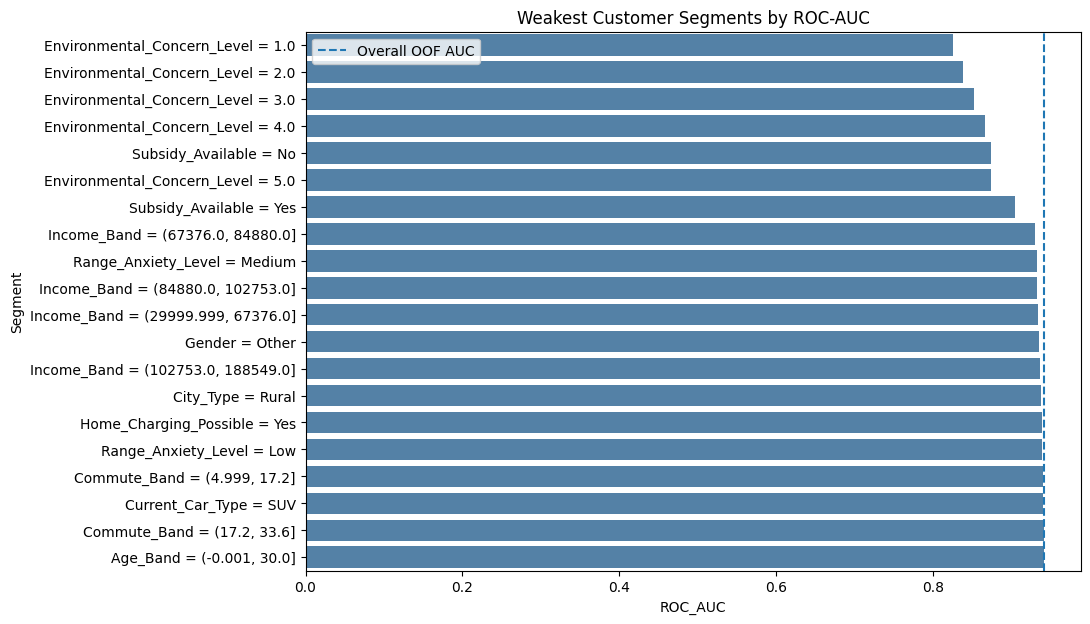

In [32]:
plot_subgroups = subgroup_auc_df.sort_values("ROC_AUC").head(20).copy()
plot_subgroups["Segment"] = plot_subgroups["Group"] + " = " + plot_subgroups["Level"]

plt.figure(figsize=(10, 7))
sns.barplot(data=plot_subgroups, x="ROC_AUC", y="Segment", color="steelblue")
plt.axvline(best_oof_auc, linestyle="--", label="Overall OOF AUC")
plt.title("Weakest Customer Segments by ROC-AUC")
plt.legend()
plt.show()

Overall AUC can hide weak segments. The worst subgroup gap is a direct clue for the next feature-engineering notebook: interactions should target the places where ranking quality actually collapses.

## Interaction Error Heatmaps

In [33]:
diagnostic_df["Total_Charging_Stations"] = (
    diagnostic_df["Charging_Stations_Near_Home"] +
    diagnostic_df["Charging_Stations_Near_Work"]
)
diagnostic_df["Charging_Band"] = pd.qcut(diagnostic_df["Total_Charging_Stations"], 4, duplicates="drop")
diagnostic_df["Bias"] = diagnostic_df["Probability"] - diagnostic_df["Actual"]


def interaction_bias_table(df, row_col, col_col):
    table = (
        df.groupby([row_col, col_col], observed=False)
        .agg(
            Rows=("Actual", "size"),
            Actual_Rate=("Actual", "mean"),
            Predicted_Rate=("Probability", "mean")
        )
        .reset_index()
    )
    table["Bias"] = table["Predicted_Rate"] - table["Actual_Rate"]
    return table

interaction_specs = [
    ("Income_Band", "Environmental_Concern_Level"),
    ("Range_Anxiety_Level", "Subsidy_Available"),
    ("Range_Anxiety_Level", "Home_Charging_Possible"),
    ("Commute_Band", "Charging_Band")
]

interaction_tables = {}
for row_col, col_col in interaction_specs:
    t = interaction_bias_table(diagnostic_df, row_col, col_col)
    interaction_tables[f"{row_col}__{col_col}"] = t

interaction_tables[list(interaction_tables)[0]].head()

,Income_Band,Environmental_Concern_Level,Rows,Actual_Rate,Predicted_Rate,Bias
0,"(29999.999, 67376.0]",1.000000,39766,0.001484,0.001614,0.000131
1,"(29999.999, 67376.0]",2.000000,37685,0.006024,0.006276,0.000253
2,"(29999.999, 67376.0]",3.000000,33493,0.035291,0.035116,-0.000175
3,"(29999.999, 67376.0]",4.000000,31760,0.089295,0.089745,0.000450
4,"(29999.999, 67376.0]",5.000000,24464,0.237696,0.237943,0.000247


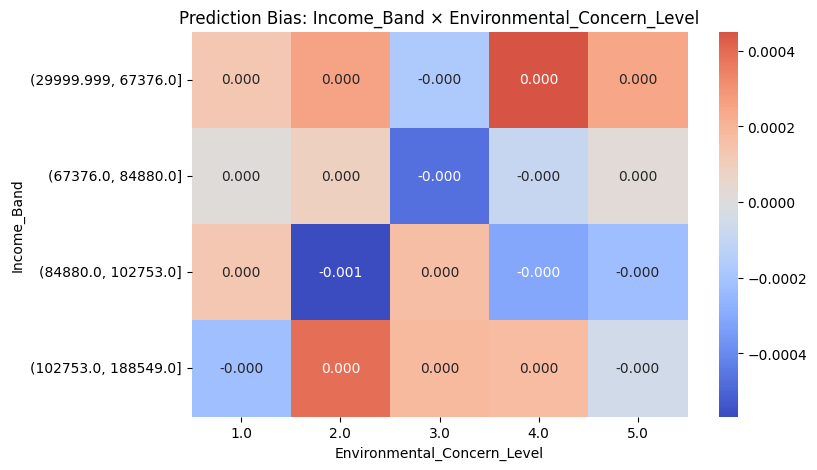

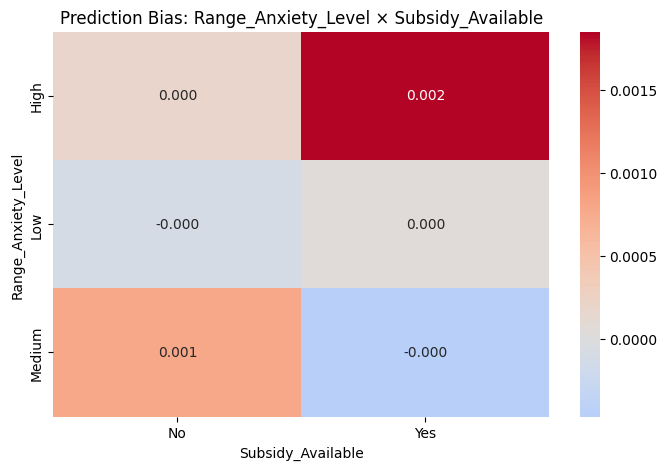

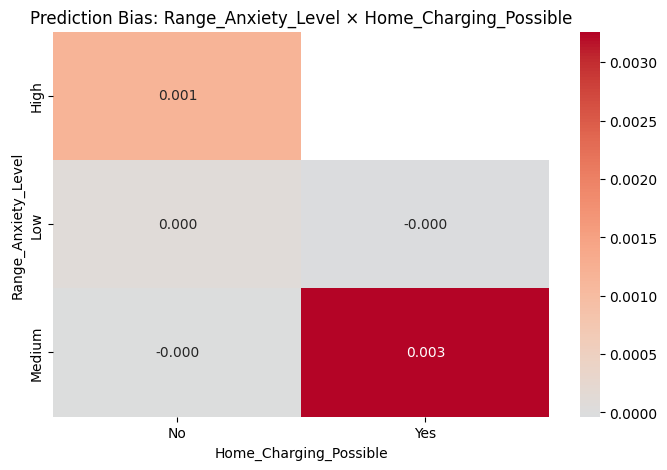

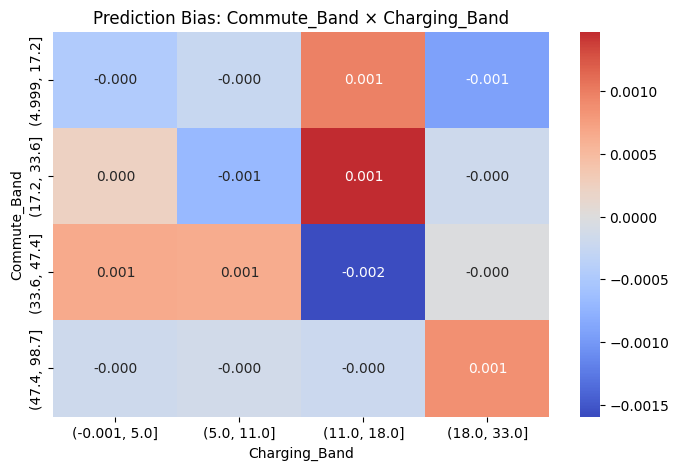

In [34]:
for key, table in interaction_tables.items():
    row_col, col_col = key.split("__")
    pivot = table.pivot(index=row_col, columns=col_col, values="Bias")

    plt.figure(figsize=(8, 5))
    sns.heatmap(pivot, annot=True, fmt=".3f", center=0, cmap="coolwarm")
    plt.title(f"Prediction Bias: {row_col} × {col_col}")
    plt.show()

Positive bias means the model over-predicts EV purchase for that interaction cell; negative bias means it under-predicts. These heatmaps are much more actionable than blindly multiplying every pair of features.

## SHAP Analysis

In [35]:
lgb_holdout = holdout_models["Tuned LightGBM"]

if RUN_SHAP and SHAP_AVAILABLE:
    shap_n = min(SHAP_SAMPLE, len(X_valid))
    shap_idx = np.random.default_rng(RANDOM_STATE).choice(len(X_valid), shap_n, replace=False)
    X_shap = X_valid.iloc[shap_idx].copy()

    shap_explainer = shap.TreeExplainer(lgb_holdout)
    raw_shap_values = shap_explainer.shap_values(X_shap)

    if isinstance(raw_shap_values, list):
        shap_values = np.asarray(raw_shap_values[-1])
    else:
        shap_values = np.asarray(raw_shap_values)
        if shap_values.ndim == 3:
            shap_values = shap_values[:, :, -1]

    shap_importance = pd.DataFrame({
        "Feature": X_shap.columns,
        "SHAP_MeanAbs": np.abs(shap_values).mean(axis=0)
    }).sort_values("SHAP_MeanAbs", ascending=False)
else:
    X_shap = pd.DataFrame()
    shap_values = None
    shap_importance = pd.DataFrame(columns=["Feature", "SHAP_MeanAbs"])

shap_importance.head(15)

,Feature,SHAP_MeanAbs


In [36]:
if RUN_SHAP and SHAP_AVAILABLE and shap_values is not None:
    shap.summary_plot(shap_values, X_shap, plot_type="bar", show=False, max_display=15)
    plt.title("SHAP Global Importance")
    plt.show()

    shap.summary_plot(shap_values, X_shap, show=False, max_display=15)
    plt.title("SHAP Direction and Magnitude")
    plt.show()

In [37]:
if RUN_SHAP and SHAP_AVAILABLE and shap_values is not None:
    for feature in shap_importance.head(3)["Feature"]:
        shap.dependence_plot(feature, shap_values, X_shap, show=False)
        plt.title(f"SHAP Dependence — {feature}")
        plt.show()

Normal split importance only says a feature was used. SHAP tells us **how strongly and in which direction** a feature moves predictions for individual customers.

## SHAP Interaction Analysis

In [38]:
if RUN_SHAP_INTERACTIONS and SHAP_AVAILABLE:
    interaction_n = min(SHAP_INTERACTION_SAMPLE, len(X_valid))
    interaction_idx = np.random.default_rng(RANDOM_STATE + 1).choice(len(X_valid), interaction_n, replace=False)
    X_shap_inter = X_valid.iloc[interaction_idx].copy()

    try:
        raw_interactions = shap.TreeExplainer(lgb_holdout).shap_interaction_values(X_shap_inter)
        if isinstance(raw_interactions, list):
            interaction_values = np.asarray(raw_interactions[-1])
        else:
            interaction_values = np.asarray(raw_interactions)
            if interaction_values.ndim == 4:
                interaction_values = interaction_values[:, :, :, -1]

        mean_interactions = np.abs(interaction_values).mean(axis=0)
        np.fill_diagonal(mean_interactions, 0.0)

        interaction_rows = []
        for i in range(len(X.columns)):
            for j in range(i + 1, len(X.columns)):
                interaction_rows.append({
                    "Feature_1": X.columns[i],
                    "Feature_2": X.columns[j],
                    "MeanAbs_SHAP_Interaction": mean_interactions[i, j]
                })

        shap_interaction_df = pd.DataFrame(interaction_rows).sort_values(
            "MeanAbs_SHAP_Interaction", ascending=False
        )
    except Exception as exc:
        print("SHAP interaction analysis skipped:", exc)
        mean_interactions = None
        shap_interaction_df = pd.DataFrame(columns=["Feature_1", "Feature_2", "MeanAbs_SHAP_Interaction"])
else:
    mean_interactions = None
    shap_interaction_df = pd.DataFrame(columns=["Feature_1", "Feature_2", "MeanAbs_SHAP_Interaction"])

shap_interaction_df.head(15)

,Feature_1,Feature_2,MeanAbs_SHAP_Interaction


In [39]:
if not shap_interaction_df.empty:
    top_pairs = shap_interaction_df.head(15).copy()
    top_pairs["Pair"] = top_pairs["Feature_1"] + " × " + top_pairs["Feature_2"]

    plt.figure(figsize=(10, 7))
    sns.barplot(data=top_pairs, x="MeanAbs_SHAP_Interaction", y="Pair", color="steelblue")
    plt.title("Strongest SHAP Feature Interactions")
    plt.show()

This section tests whether our current engineered interactions are actually the interactions the model cares about. Strong unseen pairs are candidates for Notebook 05; weak engineered pairs are candidates for removal.

## Permutation Importance

In [40]:
if RUN_PERMUTATION:
    perm_n = min(PERMUTATION_SAMPLE, len(X_valid))
    perm_idx = np.random.default_rng(RANDOM_STATE + 2).choice(len(X_valid), perm_n, replace=False)
    X_perm = X_valid.iloc[perm_idx]
    y_perm = y_valid.iloc[perm_idx]

    perm = permutation_importance(
        lgb_holdout,
        X_perm,
        y_perm,
        scoring="roc_auc",
        n_repeats=2 if FAST_MODE else 3,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    permutation_df = pd.DataFrame({
        "Feature": X.columns,
        "Permutation_Mean": perm.importances_mean,
        "Permutation_Std": perm.importances_std
    }).sort_values("Permutation_Mean", ascending=False)
else:
    permutation_df = pd.DataFrame(columns=["Feature", "Permutation_Mean", "Permutation_Std"])

permutation_df.head(15)

,Feature,Permutation_Mean,Permutation_Std
13,Subsidy_x_Concern,0.092218,0.001939
16,Income_x_Concern,0.033372,0.000765
1,Annual_Income_USD,0.016528,0.000618
6,Environmental_Concern_Level,0.006792,0.000161
17,Subsidy_x_Income,0.004661,0.000310
9,Range_Anxiety_Level,0.003702,0.000208
2,Daily_Commute_km,0.002053,0.000098
14,Subsidy_x_LowAnxiety,0.001984,0.000156
11,Income_Per_Car,0.001070,0.000008
0,Age,0.000638,0.000093


In [41]:
gain_df = pd.DataFrame({
    "Feature": X.columns,
    "Gain_Importance": lgb_holdout.feature_importances_
})

importance_compare = gain_df.merge(shap_importance, on="Feature", how="left")
importance_compare = importance_compare.merge(permutation_df, on="Feature", how="left")
importance_compare = importance_compare.merge(
    importance_stability.rename(columns={"mean": "CV_Importance_Mean", "std": "CV_Importance_Std"}),
    on="Feature",
    how="left"
)

importance_compare.sort_values("Permutation_Mean", ascending=False).head(15)

,Feature,Gain_Importance,SHAP_MeanAbs,Permutation_Mean,Permutation_Std,CV_Importance_Mean,CV_Importance_Std
13,Subsidy_x_Concern,358,NaN,0.092218,0.001939,432.400000,31.173707
16,Income_x_Concern,3132,NaN,0.033372,0.000765,"3,132.000000",95.679151
1,Annual_Income_USD,3248,NaN,0.016528,0.000618,"3,319.200000",68.170375
6,Environmental_Concern_Level,510,NaN,0.006792,0.000161,483.800000,26.929538
17,Subsidy_x_Income,2802,NaN,0.004661,0.000310,"2,636.400000",93.681909
9,Range_Anxiety_Level,477,NaN,0.003702,0.000208,433.200000,13.217413
2,Daily_Commute_km,3472,NaN,0.002053,0.000098,"3,659.200000",120.298379
14,Subsidy_x_LowAnxiety,135,NaN,0.001984,0.000156,127.800000,6.760178
11,Income_Per_Car,2474,NaN,0.001070,0.000008,"2,601.000000",84.068425
0,Age,2640,NaN,0.000638,0.000093,"2,732.800000",107.166693


If split importance is high but permutation importance is near zero, the feature may be redundant. Agreement across gain, SHAP, permutation, and fold stability is much stronger evidence that a feature is truly useful.

## Feature Redundancy

In [42]:
spearman_corr = X.corr(method="spearman")

redundant_rows = []
for i, f1 in enumerate(X.columns):
    for j in range(i + 1, len(X.columns)):
        f2 = X.columns[j]
        corr = spearman_corr.iloc[i, j]
        if abs(corr) >= 0.90:
            redundant_rows.append({
                "Feature_1": f1,
                "Feature_2": f2,
                "Spearman": corr
            })

redundancy_df = pd.DataFrame(redundant_rows)
if not redundancy_df.empty:
    redundancy_df = redundancy_df.sort_values("Spearman", key=lambda s: s.abs(), ascending=False)

redundancy_df.head(20)

,Feature_1,Feature_2,Spearman
1,Range_Anxiety_Level,Low_Range_Anxiety,-0.999830
0,Charging_Stations_Near_Work,Total_Charging_Stations,0.903215


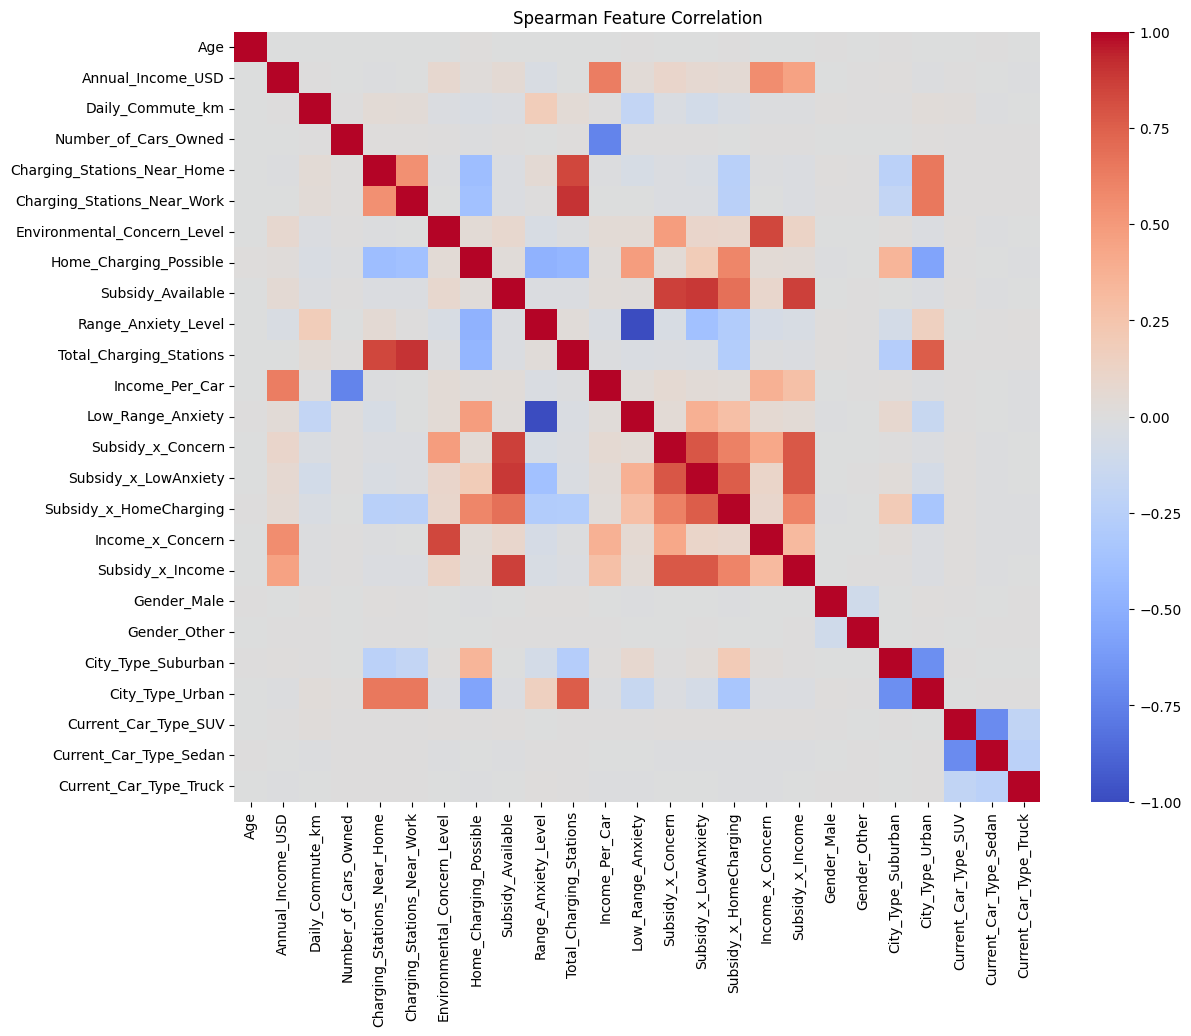

In [43]:
plt.figure(figsize=(13, 10))
sns.heatmap(spearman_corr, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Spearman Feature Correlation")
plt.show()

Engineered features are useful only if they add information. Strong correlation is not automatically bad for tree models, but it is a warning that two features may be describing almost the same signal.

## Feature Ablation Study

In [44]:
engineered_groups = {
    "All_Engineered": [
        "Total_Charging_Stations",
        "Income_Per_Car",
        "Low_Range_Anxiety",
        "Subsidy_x_Concern",
        "Subsidy_x_LowAnxiety",
        "Subsidy_x_HomeCharging",
        "Income_x_Concern",
        "Subsidy_x_Income"
    ],
    "Charging_Summary": ["Total_Charging_Stations"],
    "Affordability": ["Income_Per_Car"],
    "Anxiety_Indicator": ["Low_Range_Anxiety"],
    "Subsidy_Interactions": [
        "Subsidy_x_Concern",
        "Subsidy_x_LowAnxiety",
        "Subsidy_x_HomeCharging",
        "Subsidy_x_Income"
    ],
    "Income_Concern": ["Income_x_Concern"]
}

engineered_groups = {
    name: [f for f in features if f in X.columns]
    for name, features in engineered_groups.items()
}
engineered_groups

{'All_Engineered': ['Total_Charging_Stations',
  'Income_Per_Car',
  'Low_Range_Anxiety',
  'Subsidy_x_Concern',
  'Subsidy_x_LowAnxiety',
  'Subsidy_x_HomeCharging',
  'Income_x_Concern',
  'Subsidy_x_Income'],
 'Charging_Summary': ['Total_Charging_Stations'],
 'Affordability': ['Income_Per_Car'],
 'Anxiety_Indicator': ['Low_Range_Anxiety'],
 'Subsidy_Interactions': ['Subsidy_x_Concern',
  'Subsidy_x_LowAnxiety',
  'Subsidy_x_HomeCharging',
  'Subsidy_x_Income'],
 'Income_Concern': ['Income_x_Concern']}

In [45]:
if RUN_ABLATION:
    rng = np.random.default_rng(RANDOM_STATE + 3)
    ab_train_idx = rng.choice(len(X_train), min(HEAVY_SAMPLE, len(X_train)), replace=False)
    ab_valid_idx = rng.choice(len(X_valid), min(max(4_000, HEAVY_SAMPLE // 4), len(X_valid)), replace=False)

    X_ab_train = X_train.iloc[ab_train_idx]
    y_ab_train = y_train.iloc[ab_train_idx]
    X_ab_valid = X_valid.iloc[ab_valid_idx]
    y_ab_valid = y_valid.iloc[ab_valid_idx]

    baseline_ab_model = make_lgb(rounds=min(lgb_rounds, 500 if not FAST_MODE else 120))
    baseline_ab_model.fit(X_ab_train, y_ab_train)
    baseline_ab_prob = baseline_ab_model.predict_proba(X_ab_valid)[:, 1]
    baseline_ab_auc = roc_auc_score(y_ab_valid, baseline_ab_prob)

    ablation_rows = [{
        "Experiment": "Full_Feature_Set",
        "Removed_Features": 0,
        "ROC_AUC": baseline_ab_auc,
        "Delta_vs_Full": 0.0
    }]

    for group_name, remove_features in engineered_groups.items():
        keep_cols = [c for c in X.columns if c not in remove_features]
        model = make_lgb(rounds=min(lgb_rounds, 500 if not FAST_MODE else 120))
        model.fit(X_ab_train[keep_cols], y_ab_train)
        prob = model.predict_proba(X_ab_valid[keep_cols])[:, 1]
        auc = roc_auc_score(y_ab_valid, prob)

        ablation_rows.append({
            "Experiment": f"Remove_{group_name}",
            "Removed_Features": len(remove_features),
            "ROC_AUC": auc,
            "Delta_vs_Full": auc - baseline_ab_auc
        })

    ablation_df = pd.DataFrame(ablation_rows).sort_values("Delta_vs_Full")
else:
    ablation_df = pd.DataFrame(columns=["Experiment", "Removed_Features", "ROC_AUC", "Delta_vs_Full"])

ablation_df

,Experiment,Removed_Features,ROC_AUC,Delta_vs_Full
5,Remove_Subsidy_Interactions,4,0.942486,-0.000014
0,Full_Feature_Set,0,0.942500,0.000000
2,Remove_Charging_Summary,1,0.942519,0.000019
1,Remove_All_Engineered,8,0.942552,0.000052
4,Remove_Anxiety_Indicator,1,0.942572,0.000072
6,Remove_Income_Concern,1,0.942589,0.000089
3,Remove_Affordability,1,0.942636,0.000136


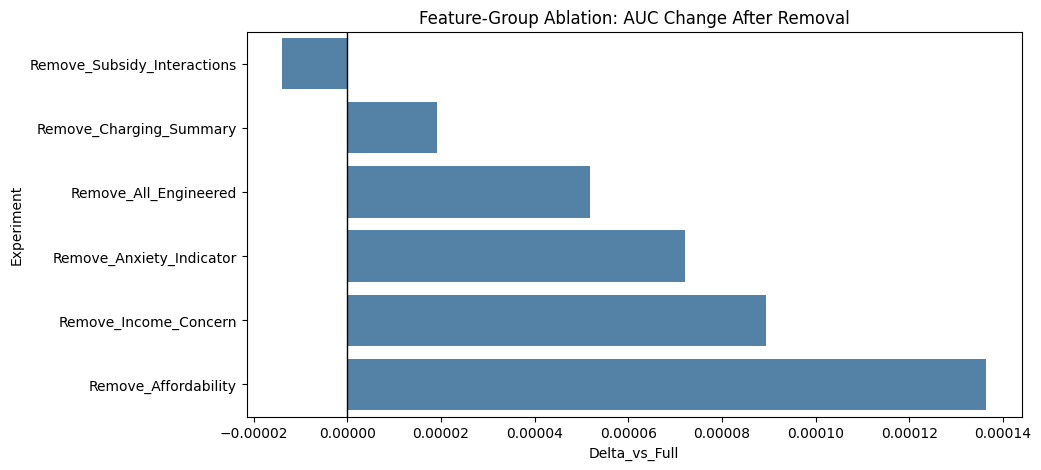

In [46]:
if not ablation_df.empty:
    plt.figure(figsize=(10, 5))
    plot_ablation = ablation_df[ablation_df["Experiment"] != "Full_Feature_Set"].copy()
    sns.barplot(data=plot_ablation, x="Delta_vs_Full", y="Experiment", color="steelblue")
    plt.axvline(0, color="black", linewidth=1)
    plt.title("Feature-Group Ablation: AUC Change After Removal")
    plt.show()

A feature group is valuable when removing it consistently hurts AUC. If removing a group improves AUC, that group may be noisy or redundant and should be reconsidered before adding anything new.

## Adversarial Validation

In [47]:
if RUN_ADVERSARIAL:
    n_domain = min(DOMAIN_SAMPLE, len(X), len(X_kaggle))
    rng = np.random.default_rng(RANDOM_STATE + 4)

    train_domain_idx = rng.choice(len(X), n_domain, replace=False)
    test_domain_idx = rng.choice(len(X_kaggle), n_domain, replace=False)

    domain_X = pd.concat([
        X.iloc[train_domain_idx],
        X_kaggle.iloc[test_domain_idx]
    ], ignore_index=True)
    domain_y = pd.Series(np.r_[np.zeros(n_domain), np.ones(n_domain)], name="Is_Kaggle_Test")

    dX_train, dX_valid, dy_train, dy_valid = train_test_split(
        domain_X,
        domain_y,
        test_size=0.25,
        stratify=domain_y,
        random_state=RANDOM_STATE
    )

    domain_model = LGBMClassifier(
        n_estimators=120 if FAST_MODE else 350,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=40,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbosity=-1
    )
    domain_model.fit(dX_train, dy_train)
    domain_prob = domain_model.predict_proba(dX_valid)[:, 1]
    adversarial_auc = roc_auc_score(dy_valid, domain_prob)

    domain_importance = pd.DataFrame({
        "Feature": X.columns,
        "Domain_Importance": domain_model.feature_importances_
    }).sort_values("Domain_Importance", ascending=False)
else:
    adversarial_auc = np.nan
    domain_importance = pd.DataFrame(columns=["Feature", "Domain_Importance"])

print("Adversarial validation AUC:", round(float(adversarial_auc), 6) if pd.notna(adversarial_auc) else "skipped")
domain_importance.head(15)

Adversarial validation AUC: 0.499996


,Feature,Domain_Importance
2,Daily_Commute_km,1777
0,Age,1317
16,Income_x_Concern,1277
11,Income_Per_Car,1074
1,Annual_Income_USD,992
10,Total_Charging_Stations,760
5,Charging_Stations_Near_Work,663
17,Subsidy_x_Income,617
4,Charging_Stations_Near_Home,588
18,Gender_Male,191


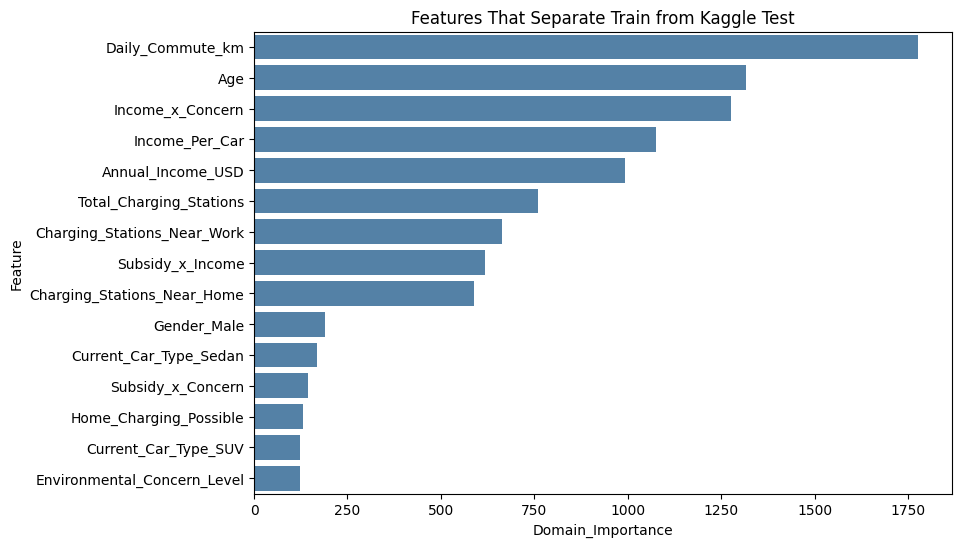

In [48]:
if not domain_importance.empty:
    plt.figure(figsize=(9, 6))
    sns.barplot(data=domain_importance.head(15), x="Domain_Importance", y="Feature", color="steelblue")
    plt.title("Features That Separate Train from Kaggle Test")
    plt.show()

Adversarial AUC near 0.50 means train and test are hard to distinguish. A clearly higher score means distribution shift exists and local CV may be optimistic for the leaderboard.

## Train/Test Feature Drift

In [49]:
def psi_score(expected, actual, bins=10, eps=1e-6):
    expected = pd.Series(expected).dropna()
    actual = pd.Series(actual).dropna()

    unique_values = np.unique(expected)
    if len(unique_values) <= 10:
        categories = np.union1d(expected.unique(), actual.unique())
        e = expected.value_counts(normalize=True).reindex(categories, fill_value=0).values + eps
        a = actual.value_counts(normalize=True).reindex(categories, fill_value=0).values + eps
        return float(np.sum((a - e) * np.log(a / e)))

    edges = np.unique(np.quantile(expected, np.linspace(0, 1, bins + 1)))
    if len(edges) < 3:
        return 0.0

    edges[0] = -np.inf
    edges[-1] = np.inf

    e_counts, _ = np.histogram(expected, bins=edges)
    a_counts, _ = np.histogram(actual, bins=edges)

    e = e_counts / max(e_counts.sum(), 1) + eps
    a = a_counts / max(a_counts.sum(), 1) + eps

    return float(np.sum((a - e) * np.log(a / e)))


drift_rows = []
for feature in X.columns:
    ks = ks_2samp(X[feature], X_kaggle[feature]).statistic
    psi = psi_score(X[feature], X_kaggle[feature])

    drift_rows.append({
        "Feature": feature,
        "KS_Statistic": ks,
        "PSI": psi,
        "Mean_Train": X[feature].mean(),
        "Mean_Test": X_kaggle[feature].mean()
    })

drift_df = pd.DataFrame(drift_rows).sort_values(["PSI", "KS_Statistic"], ascending=False)
drift_df.head(15)

,Feature,KS_Statistic,PSI,Mean_Train,Mean_Test
10,Total_Charging_Stations,0.003559,0.000089,12.136722,12.106319
11,Income_Per_Car,0.002514,0.000070,"58,754.583977","58,680.394285"
9,Range_Anxiety_Level,0.001401,0.000062,0.100031,0.098939
5,Charging_Stations_Near_Work,0.003005,0.000043,7.176314,7.155626
1,Annual_Income_USD,0.001639,0.000041,"84,769.266989","84,799.508432"
2,Daily_Commute_km,0.001067,0.000031,32.158298,32.159305
0,Age,0.002293,0.000030,47.039171,47.070824
3,Number_of_Cars_Owned,0.001660,0.000026,1.712626,1.716095
13,Subsidy_x_Concern,0.001455,0.000025,1.901421,1.903839
4,Charging_Stations_Near_Home,0.001579,0.000025,4.960408,4.950693


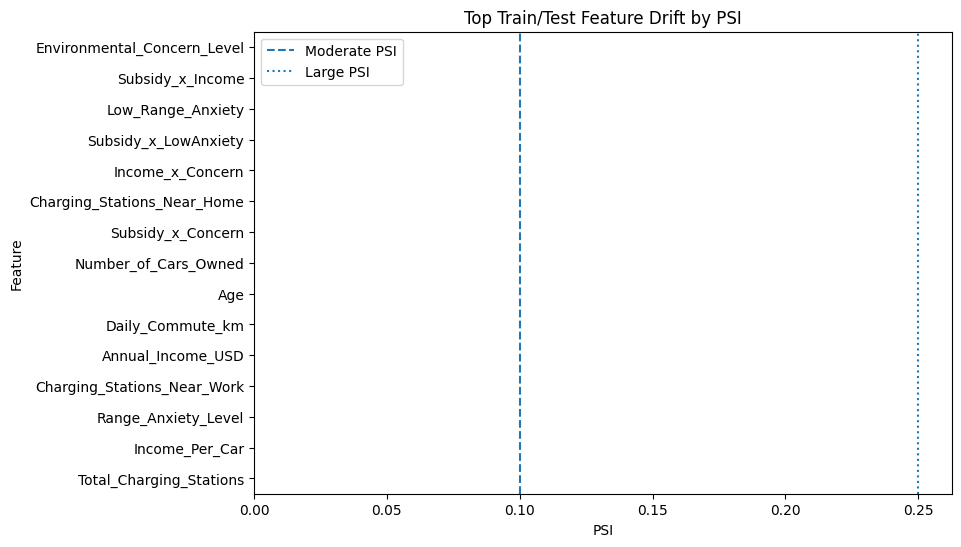

In [50]:
plot_drift = drift_df.head(15).sort_values("PSI")
plt.figure(figsize=(9, 6))
sns.barplot(data=plot_drift, x="PSI", y="Feature", color="steelblue")
plt.axvline(0.10, linestyle="--", label="Moderate PSI")
plt.axvline(0.25, linestyle=":", label="Large PSI")
plt.title("Top Train/Test Feature Drift by PSI")
plt.legend()
plt.show()

PSI and KS rank the features most responsible for train/test mismatch. Drift-heavy features deserve extra scrutiny before the next modeling round.

## Model Disagreement Analysis

In [51]:
oof_model_df = pd.DataFrame({
    "LightGBM": oof_lgb,
    "XGBoost": oof_xgb,
    "CatBoost": oof_cat
})

pearson_corr = oof_model_df.corr(method="pearson")
spearman_corr_models = oof_model_df.corr(method="spearman")

print("Pearson prediction correlation:")
display(pearson_corr)
print("Spearman rank correlation:")
display(spearman_corr_models)

Pearson prediction correlation:


,LightGBM,XGBoost,CatBoost
LightGBM,1.000000,0.997470,0.996941
XGBoost,0.997470,1.000000,0.997317
CatBoost,0.996941,0.997317,1.000000


Spearman rank correlation:


,LightGBM,XGBoost,CatBoost
LightGBM,1.000000,0.996738,0.992957
XGBoost,0.996738,1.000000,0.993523
CatBoost,0.992957,0.993523,1.000000


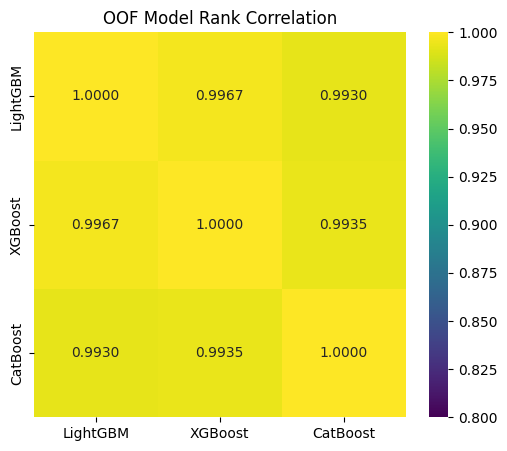

In [52]:
plt.figure(figsize=(6, 5))
sns.heatmap(spearman_corr_models, annot=True, fmt=".4f", vmin=0.8, vmax=1.0, cmap="viridis")
plt.title("OOF Model Rank Correlation")
plt.show()

In [53]:
disagreement = oof_model_df.max(axis=1) - oof_model_df.min(axis=1)
disagreement_cut = disagreement.quantile(0.99)

disagreement_df = diagnostic_df.copy()
disagreement_df["LightGBM"] = oof_lgb
disagreement_df["XGBoost"] = oof_xgb
disagreement_df["CatBoost"] = oof_cat
disagreement_df["Model_Disagreement"] = disagreement.values

top_disagreement = disagreement_df[disagreement_df["Model_Disagreement"] >= disagreement_cut].copy()

print("99th percentile disagreement:", round(float(disagreement_cut), 6))
print("Top disagreement rows:", len(top_disagreement))

99th percentile disagreement: 0.105836
Top disagreement rows: 6687


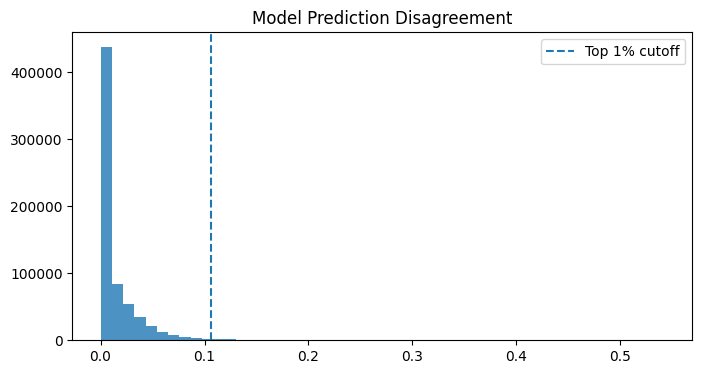

In [54]:
plt.figure(figsize=(8, 4))
plt.hist(disagreement, bins=50, alpha=0.8)
plt.axvline(disagreement_cut, linestyle="--", label="Top 1% cutoff")
plt.title("Model Prediction Disagreement")
plt.legend()
plt.show()

If the three boosting models are almost perfectly rank-correlated, blending has limited upside. The top-disagreement rows show where model diversity actually exists and where a smarter ensemble may help.

## Rank Error Analysis

In [55]:
positive_part = diagnostic_df[diagnostic_df["Actual"] == 1].copy()
negative_part = diagnostic_df[diagnostic_df["Actual"] == 0].copy()

low_positive_cut = positive_part["Probability"].quantile(0.05)
high_negative_cut = negative_part["Probability"].quantile(0.95)

lowest_ranked_positives = positive_part[positive_part["Probability"] <= low_positive_cut].copy()
highest_ranked_negatives = negative_part[negative_part["Probability"] >= high_negative_cut].copy()

print("Lowest-ranked positive cutoff:", round(float(low_positive_cut), 6))
print("Highest-ranked negative cutoff:", round(float(high_negative_cut), 6))
print("Lowest-ranked positives:", len(lowest_ranked_positives))
print("Highest-ranked negatives:", len(highest_ranked_negatives))

Lowest-ranked positive cutoff: 0.09214
Highest-ranked negative cutoff: 0.51829
Lowest-ranked positives: 5839
Highest-ranked negatives: 27595


In [56]:
rank_profile = pd.DataFrame({
    "Lowest-Ranked Positives": lowest_ranked_positives[profile_cols].mean(),
    "Highest-Ranked Negatives": highest_ranked_negatives[profile_cols].mean(),
    "Overall": diagnostic_df[profile_cols].mean()
}).T

rank_profile

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level
Lowest-Ranked Positives,46.967118,"87,459.864874",32.094742,1.713478,4.930810,7.113033,2.733345
Highest-Ranked Negatives,46.826635,"99,559.541584",30.357833,1.712955,4.813263,7.054865,4.661352
Overall,47.039171,"84,769.266989",32.158298,1.712626,4.960408,7.176314,2.935477


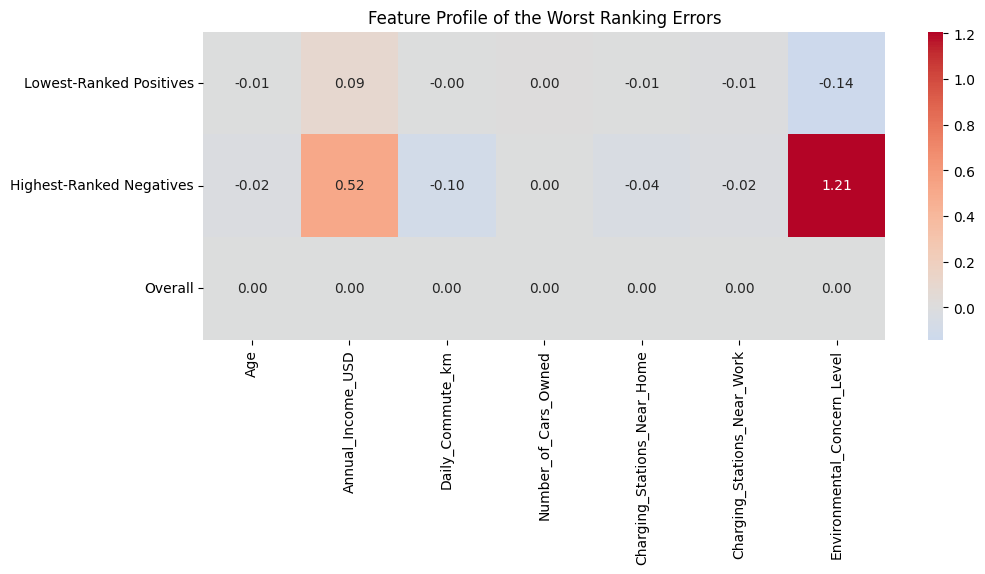

In [57]:
rank_profile_z = rank_profile.copy()
for col in profile_cols:
    mu = diagnostic_df[col].mean()
    sd = diagnostic_df[col].std(ddof=0) or 1
    rank_profile_z[col] = (rank_profile[col] - mu) / sd

plt.figure(figsize=(11, 4))
sns.heatmap(rank_profile_z, annot=True, fmt=".2f", center=0, cmap="coolwarm")
plt.title("Feature Profile of the Worst Ranking Errors")
plt.show()

This section is closer to the competition metric than a 0.50-threshold confusion matrix. We care about positives that are ranked too low and negatives that are ranked too high.

## Seed Stability

In [58]:
if RUN_SEED_STABILITY:
    rng = np.random.default_rng(RANDOM_STATE + 5)
    seed_train_idx = rng.choice(len(X_train), min(HEAVY_SAMPLE, len(X_train)), replace=False)
    seed_valid_idx = rng.choice(len(X_valid), min(max(5_000, HEAVY_SAMPLE // 4), len(X_valid)), replace=False)

    X_seed_train = X_train.iloc[seed_train_idx]
    y_seed_train = y_train.iloc[seed_train_idx]
    X_seed_valid = X_valid.iloc[seed_valid_idx]
    y_seed_valid = y_valid.iloc[seed_valid_idx]

    seed_rows = []
    seed_predictions = {}

    for seed in SEEDS:
        model = make_lgb(seed=seed, rounds=min(lgb_rounds, 600 if not FAST_MODE else 120))
        model.fit(X_seed_train, y_seed_train)
        prob = model.predict_proba(X_seed_valid)[:, 1]
        seed_predictions[str(seed)] = prob
        seed_rows.append({"Seed": seed, "ROC_AUC": roc_auc_score(y_seed_valid, prob)})

    seed_df = pd.DataFrame(seed_rows)
    seed_corr = pd.DataFrame(seed_predictions).corr(method="spearman")
else:
    seed_df = pd.DataFrame(columns=["Seed", "ROC_AUC"])
    seed_corr = pd.DataFrame()

seed_df

,Seed,ROC_AUC
0,42,0.941279
1,123,0.941144
2,2026,0.941259
3,3407,0.941189
4,777,0.941226


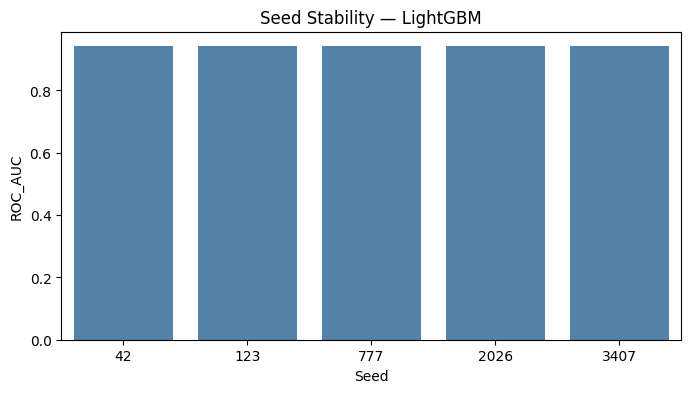

Seed AUC std: 4.8e-05


In [59]:
if not seed_df.empty:
    plt.figure(figsize=(8, 4))
    sns.barplot(data=seed_df, x="Seed", y="ROC_AUC", color="steelblue")
    plt.title("Seed Stability — LightGBM")
    plt.show()

    print("Seed AUC std:", round(float(seed_df["ROC_AUC"].std(ddof=0)), 6))

Seed sensitivity is a variance signal. If AUC or rankings change materially across seeds, seed averaging can be a legitimate ensemble improvement rather than just another hyperparameter search.

## Learning Curve

In [60]:
if RUN_LEARNING_CURVE:
    learning_rows = []
    rng = np.random.default_rng(RANDOM_STATE + 6)

    for frac in LEARNING_FRACTIONS:
        n_rows = max(1_000, int(len(X_train) * frac))
        n_rows = min(n_rows, len(X_train))

        if n_rows == len(X_train):
            subset_idx = np.arange(len(X_train))
        else:
            subset_idx, _ = train_test_split(
                np.arange(len(X_train)),
                train_size=n_rows,
                stratify=y_train,
                random_state=RANDOM_STATE
            )

        model = make_lgb(rounds=min(lgb_rounds, 600 if not FAST_MODE else 120))
        model.fit(X_train.iloc[subset_idx], y_train.iloc[subset_idx])

        train_prob = model.predict_proba(X_train.iloc[subset_idx])[:, 1]
        valid_prob = model.predict_proba(X_valid)[:, 1]

        learning_rows.append({
            "Fraction": frac,
            "Rows": len(subset_idx),
            "Train_AUC": roc_auc_score(y_train.iloc[subset_idx], train_prob),
            "Valid_AUC": roc_auc_score(y_valid, valid_prob)
        })

    learning_df = pd.DataFrame(learning_rows)
else:
    learning_df = pd.DataFrame(columns=["Fraction", "Rows", "Train_AUC", "Valid_AUC"])

learning_df

,Fraction,Rows,Train_AUC,Valid_AUC
0,0.100000,53493,0.948964,0.939740
1,0.250000,133733,0.946034,0.940877
2,0.500000,267466,0.944014,0.941441
3,0.750000,401199,0.943585,0.941563
4,1.000000,534932,0.943204,0.941651


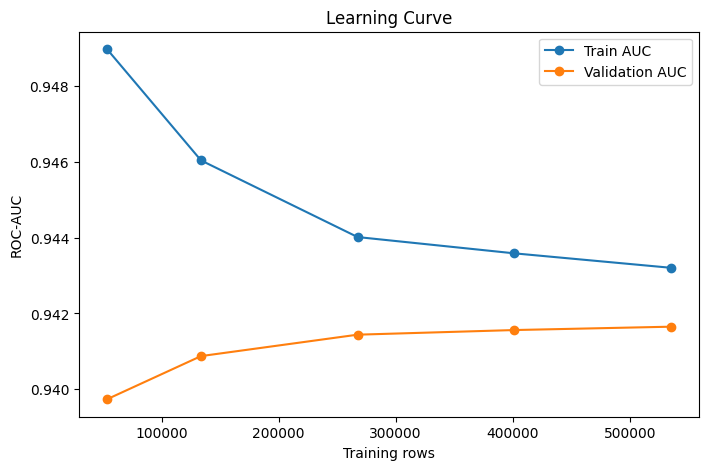

In [61]:
if not learning_df.empty:
    plt.figure(figsize=(8, 5))
    plt.plot(learning_df["Rows"], learning_df["Train_AUC"], marker="o", label="Train AUC")
    plt.plot(learning_df["Rows"], learning_df["Valid_AUC"], marker="o", label="Validation AUC")
    plt.xlabel("Training rows")
    plt.ylabel("ROC-AUC")
    plt.title("Learning Curve")
    plt.legend()
    plt.show()

If validation AUC is still climbing sharply at 100% of the data, the system is data-limited. If it has plateaued, the next gains are more likely to come from better features, CV design, or a more diverse ensemble.

## Build Unified Feature Diagnostics

In [62]:
feature_diagnostics = importance_compare.copy()
feature_diagnostics = feature_diagnostics.merge(
    drift_df[["Feature", "KS_Statistic", "PSI"]],
    on="Feature",
    how="left"
)

if not domain_importance.empty:
    feature_diagnostics = feature_diagnostics.merge(domain_importance, on="Feature", how="left")
else:
    feature_diagnostics["Domain_Importance"] = np.nan

max_corr_map = {}
for feature in X.columns:
    vals = spearman_corr.loc[feature].drop(feature).abs()
    max_corr_map[feature] = vals.max() if len(vals) else 0.0

feature_diagnostics["Max_Abs_Spearman_With_Other_Feature"] = feature_diagnostics["Feature"].map(max_corr_map)
feature_diagnostics.sort_values("Permutation_Mean", ascending=False).head(20)

,Feature,Gain_Importance,SHAP_MeanAbs,Permutation_Mean,Permutation_Std,CV_Importance_Mean,CV_Importance_Std,KS_Statistic,PSI,Domain_Importance,Max_Abs_Spearman_With_Other_Feature
13,Subsidy_x_Concern,358,NaN,0.092218,0.001939,432.400000,31.173707,0.001455,0.000025,145,0.864210
16,Income_x_Concern,3132,NaN,0.033372,0.000765,"3,132.000000",95.679151,0.001307,0.000023,1277,0.837795
1,Annual_Income_USD,3248,NaN,0.016528,0.000618,"3,319.200000",68.170375,0.001639,0.000041,992,0.626344
6,Environmental_Concern_Level,510,NaN,0.006792,0.000161,483.800000,26.929538,0.001271,0.000020,123,0.837795
17,Subsidy_x_Income,2802,NaN,0.004661,0.000310,"2,636.400000",93.681909,0.001747,0.000022,617,0.859683
9,Range_Anxiety_Level,477,NaN,0.003702,0.000208,433.200000,13.217413,0.001401,0.000062,71,0.999830
2,Daily_Commute_km,3472,NaN,0.002053,0.000098,"3,659.200000",120.298379,0.001067,0.000031,1777,0.180234
14,Subsidy_x_LowAnxiety,135,NaN,0.001984,0.000156,127.800000,6.760178,0.002358,0.000023,70,0.886828
11,Income_Per_Car,2474,NaN,0.001070,0.000008,"2,601.000000",84.068425,0.002514,0.000070,1074,0.738990
0,Age,2640,NaN,0.000638,0.000093,"2,732.800000",107.166693,0.002293,0.000030,1317,0.008702


## Problem Ranking

In [63]:
def severity(value, medium, high, higher_is_worse=True):
    if pd.isna(value):
        return "UNKNOWN"

    score = value if higher_is_worse else -value
    med = medium if higher_is_worse else -medium
    hi = high if higher_is_worse else -high

    if score >= hi:
        return "HIGH"
    if score >= med:
        return "MEDIUM"
    return "LOW"

current_generalization = generalization_df.set_index("Model").loc[current_choice]
overfit_gap = float(current_generalization["AUC_Gap"])
fold_std = float(cv_summary.loc["LightGBM", "std"])
worst_subgroup_auc = float(subgroup_auc_df["ROC_AUC"].min()) if not subgroup_auc_df.empty else np.nan
subgroup_gap = float(best_oof_auc - worst_subgroup_auc) if pd.notna(worst_subgroup_auc) else np.nan
mean_model_corr = float(
    spearman_corr_models.values[np.triu_indices_from(spearman_corr_models.values, k=1)].mean()
)
seed_auc_std = float(seed_df["ROC_AUC"].std(ddof=0)) if not seed_df.empty else np.nan
max_psi = float(drift_df["PSI"].max())

stored_best_single_auc = max(
    [v for k, v in stored_validation_auc.items() if k != "Blend"],
    default=np.nan
)
stored_blend_auc = stored_validation_auc.get("Blend", np.nan)
holdout_blend_gain = stored_blend_auc - stored_best_single_auc if pd.notna(stored_blend_auc) and pd.notna(stored_best_single_auc) else np.nan
oof_blend_gain = best_oof_auc - max(oof_single_auc.values())
blend_gain_gap = holdout_blend_gain - oof_blend_gain if pd.notna(holdout_blend_gain) else np.nan

ablation_best_improvement = (
    float(ablation_df["Delta_vs_Full"].max())
    if not ablation_df.empty else np.nan
)

learning_last_gain = (
    float(learning_df["Valid_AUC"].iloc[-1] - learning_df["Valid_AUC"].iloc[-2])
    if len(learning_df) >= 2 else np.nan
)

problem_rows = [
    {
        "Problem": "Generalization gap / overfitting",
        "Evidence": f"Train-valid AUC gap = {overfit_gap:.6f}",
        "Severity": severity(overfit_gap, 0.005, 0.015),
        "Likely_Fix": "Regularize tree complexity, verify early stopping, or reduce noisy interactions."
    },
    {
        "Problem": "Fold instability",
        "Evidence": f"LightGBM fold AUC std = {fold_std:.6f}",
        "Severity": severity(fold_std, 0.0010, 0.0030),
        "Likely_Fix": "Use stronger CV, seed averaging, and avoid features whose importance changes sharply across folds."
    },
    {
        "Problem": "Calibration distortion",
        "Evidence": f"ECE = {ece:.6f}; Brier = {brier:.6f}",
        "Severity": severity(ece, 0.015, 0.030),
        "Likely_Fix": "Useful for probability quality; lower priority than ranking unless it aligns with subgroup errors."
    },
    {
        "Problem": "Weak customer subgroups",
        "Evidence": f"Overall-to-worst subgroup AUC gap = {subgroup_gap:.6f}",
        "Severity": severity(subgroup_gap, 0.020, 0.050),
        "Likely_Fix": "Create evidence-based interactions for the weak segment and test them with ablation."
    },
    {
        "Problem": "Train/test distribution shift",
        "Evidence": f"Adversarial AUC = {adversarial_auc:.6f}; max PSI = {max_psi:.4f}",
        "Severity": "HIGH" if (pd.notna(adversarial_auc) and adversarial_auc >= 0.60) or max_psi >= 0.25 else ("MEDIUM" if (pd.notna(adversarial_auc) and adversarial_auc >= 0.55) or max_psi >= 0.10 else "LOW"),
        "Likely_Fix": "Downweight drift-heavy features, use robust validation, and avoid overfitting train-specific interactions."
    },
    {
        "Problem": "Low ensemble diversity",
        "Evidence": f"Mean OOF rank correlation = {mean_model_corr:.6f}",
        "Severity": severity(mean_model_corr, 0.985, 0.995),
        "Likely_Fix": "Add genuinely different representations/models; simple blends cannot help much when ranks are nearly identical."
    },
    {
        "Problem": "Seed sensitivity",
        "Evidence": f"Seed AUC std = {seed_auc_std:.6f}" if pd.notna(seed_auc_std) else "Skipped",
        "Severity": severity(seed_auc_std, 0.0005, 0.0015),
        "Likely_Fix": "Use seed averaging if instability is meaningful."
    },
    {
        "Problem": "Noisy / redundant engineered features",
        "Evidence": f"Best AUC change after removing a feature group = {ablation_best_improvement:.6f}" if pd.notna(ablation_best_improvement) else "Skipped",
        "Severity": severity(ablation_best_improvement, 0.0003, 0.0010),
        "Likely_Fix": "Remove or redesign feature groups whose removal improves validation AUC."
    },
    {
        "Problem": "Holdout blend-weight overfitting",
        "Evidence": f"Holdout gain - OOF gain = {blend_gain_gap:.6f}" if pd.notna(blend_gain_gap) else "No stored holdout blend score",
        "Severity": severity(blend_gain_gap, 0.0003, 0.0010),
        "Likely_Fix": "Choose blend weights from OOF predictions, then retrain full models once."
    },
    {
        "Problem": "Feature/model plateau",
        "Evidence": f"Last learning-curve validation gain = {learning_last_gain:.6f}" if pd.notna(learning_last_gain) else "Skipped",
        "Severity": "HIGH" if pd.notna(learning_last_gain) and learning_last_gain < 0.0002 else ("MEDIUM" if pd.notna(learning_last_gain) and learning_last_gain < 0.0007 else "LOW"),
        "Likely_Fix": "If plateaued, prioritize better interactions/representations over more data or more trees."
    }
]

problem_summary = pd.DataFrame(problem_rows)
severity_order = pd.Categorical(problem_summary["Severity"], categories=["HIGH", "MEDIUM", "LOW", "UNKNOWN"], ordered=True)
problem_summary = problem_summary.assign(_severity=severity_order).sort_values("_severity").drop(columns="_severity")
problem_summary

,Problem,Evidence,Severity,Likely_Fix
3,Weak customer subgroups,Overall-to-worst subgroup AUC gap = 0.116575,HIGH,Create evidence-based interactions for the wea...
9,Feature/model plateau,Last learning-curve validation gain = 0.000088,HIGH,"If plateaued, prioritize better interactions/r..."
5,Low ensemble diversity,Mean OOF rank correlation = 0.994406,MEDIUM,Add genuinely different representations/models...
0,Generalization gap / overfitting,Train-valid AUC gap = 0.004532,LOW,"Regularize tree complexity, verify early stopp..."
1,Fold instability,LightGBM fold AUC std = 0.000814,LOW,"Use stronger CV, seed averaging, and avoid fea..."
2,Calibration distortion,ECE = 0.000645; Brier = 0.070824,LOW,Useful for probability quality; lower priority...
4,Train/test distribution shift,Adversarial AUC = 0.499996; max PSI = 0.0001,LOW,"Downweight drift-heavy features, use robust va..."
6,Seed sensitivity,Seed AUC std = 0.000048,LOW,Use seed averaging if instability is meaningful.
7,Noisy / redundant engineered features,Best AUC change after removing a feature group...,LOW,Remove or redesign feature groups whose remova...
8,Holdout blend-weight overfitting,Holdout gain - OOF gain = -0.000010,LOW,"Choose blend weights from OOF predictions, the..."


This table is the bridge to the next stage. Notebook 05 should address **HIGH-severity problems first**, and every new feature should be tied back to one of these pieces of evidence.

## Save Diagnostic Artifacts

In [64]:
error_cases = pd.concat([
    hard_fn.assign(Issue="Hard_False_Negative"),
    hard_fp.assign(Issue="Hard_False_Positive"),
    lowest_ranked_positives.assign(Issue="Lowest_Ranked_Positive"),
    highest_ranked_negatives.assign(Issue="Highest_Ranked_Negative")
], ignore_index=True)

# Keep one row per ID + issue type, while preserving raw semantic columns.
error_cases = error_cases.drop_duplicates(subset=["id", "Issue"])

oof_predictions.to_csv(analysis_path / "oof_predictions.csv", index=False)
error_cases.to_csv(analysis_path / "error_cases.csv", index=False)
feature_diagnostics.to_csv(analysis_path / "feature_diagnostics.csv", index=False)
problem_summary.to_csv(analysis_path / "model_problem_summary.csv", index=False)

print("Saved:")
for name in [
    "oof_predictions.csv",
    "error_cases.csv",
    "feature_diagnostics.csv",
    "model_problem_summary.csv"
]:
    p = analysis_path / name
    print(f"  {name}: {p.stat().st_size / 1024:.1f} KB")

Saved:
  oof_predictions.csv: 60185.9 KB
  error_cases.csv: 9332.2 KB
  feature_diagnostics.csv: 4.1 KB
  model_problem_summary.csv: 1.6 KB


In [65]:
print("OOF predictions:", oof_predictions.shape)
print("Error cases:", error_cases.shape)
print("Feature diagnostics:", feature_diagnostics.shape)
print("Problem summary:", problem_summary.shape)

print()
print("OOF missing values:", oof_predictions.isna().sum().sum())
print("OOF probabilities inside [0,1]:", oof_predictions[["LightGBM", "XGBoost", "CatBoost", "OOF_Blend"]].apply(lambda s: s.between(0, 1).all()).all())
print("Problem severities:")
print(problem_summary["Severity"].value_counts())


OOF predictions: (668665, 6)
Error cases: (49478, 26)
Feature diagnostics: (25, 11)
Problem summary: (10, 4)

OOF missing values: 0
OOF probabilities inside [0,1]: True
Problem severities:
Severity
LOW       7
HIGH      2
MEDIUM    1
Name: count, dtype: int64


## Model Problem Analysis Summary

At this point we have moved beyond ordinary feature importance and confusion matrices.

The next feature-engineering round should be based on four kinds of evidence:

1. **Ranking failures** — positives ranked too low and negatives ranked too high.
2. **Segment failures** — customer groups with materially weaker ROC-AUC.
3. **Interaction failures** — heatmap / SHAP interaction cells where predicted and actual behavior diverge.
4. **Validation failures** — instability, drift, redundancy, seed sensitivity, or holdout-specific blend gains.

The files in `../analysis/` are now the input contract for the next advanced feature-engineering notebook. We should not add a feature simply because it sounds reasonable; it should solve a problem that appears here.